# Introduction and Background



This study examines the analytical claim: **Employees who experience a sense of belonging are more engaged."**

In today's workplaces, employee engagement and a sense of belonging are very important for productivity, retention, and the overall health of the workplace. Engagement shows how dedicated and excited an employee is about their job, while belonging shows how much they feel valued and included in the company's culture. As businesses deal with different and changing work environments, it is becoming more and more important to understand how these two dimensions are related.


The analysis utilizes the **IBM HR Analytics dataset**, which is publicly accessible on Kaggle, containing employee-level responses that reflect both belonging and engagement attributes.

To validate the analytical claim, this study employs three complementary analytical approaches:

- **Descriptive Analytics** — to summarize and explore patterns in the data
- **Inferential Analytics** — to test whether the observed relationship is statistically significant
- **Predictive Analytics** — to model and forecast engagement based on belonging-related features


#Dataset description and Loading

The dataset used in this analysis is the **IBM HR Analytics – Employee Belonging vs
Engagement** dataset, sourced from Kaggle. It contains survey-style responses from
**1,470 employees**, capturing workplace experience, satisfaction, and engagement-related attributes.

The following key columns are used in this analysis:

| Column | Description | Scale |
|---|---|---|
| `RelationshipSatisfaction` | Satisfaction with workplace relationships | 1 (Low) – 4 (Very High) |
| `EnvironmentSatisfaction` | Comfort and inclusivity of work environment | 1 (Low) – 4 (Very High) |
| `JobInvolvement` | Degree of involvement and commitment to the job | 1 (Low) – 4 (Very High) |
| `JobSatisfaction` | Overall satisfaction with the job role | 1 (Low) – 4 (Very High) |
| `Attrition` | Whether the employee left the organization | Yes / No |
| `OverTime` | Whether the employee works overtime | Yes / No |
| `Department` | Department the employee belongs to | Categorical |
| `JobRole` | Specific role of the employee | Categorical |

> **Belonging is measured using:** `RelationshipSatisfaction` and `EnvironmentSatisfaction`  
> **Engagement is measured using:** `JobInvolvement` and `JobSatisfaction`

##**Dataset Loading**

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Group_Project_Data/Employee Belonging vs Engagement.csv')
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#1. Data Preparation & Feature Engineering

####**Check for missing values**

In [ ]:
missing = df.isnull().sum()
print("=== Missing Values per Column ===")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

=== Missing Values per Column ===
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsI

###**Check for duplicate rows**

In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {num_duplicates}")

df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

Duplicate rows found: 0
Rows after removing duplicates: 1470


###**Remove useless columns**

In [ ]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f"Columns remaining: {df.shape[1]}")
print(f"Dropped columns: {cols_to_drop}")

Columns remaining: 32
Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours']


###**Fix Yes/No columns to numbers**

In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print(" Attrition and OverTime converted to numeric (1=Yes, 0=No)")
print(df[['Attrition', 'OverTime']].value_counts())

 Attrition and OverTime converted to numeric (1=Yes, 0=No)
Attrition  OverTime
0          0           944
           1           289
1          1           127
           0           110
Name: count, dtype: int64


###**Check satisfaction score ranges**

In [ ]:
sat_cols = ['RelationshipSatisfaction', 'EnvironmentSatisfaction',
            'JobInvolvement', 'JobSatisfaction', 'WorkLifeBalance']

print("=== Satisfaction Column Ranges ===")
for col in sat_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()} ")

=== Satisfaction Column Ranges ===
RelationshipSatisfaction: min=1, max=4 
EnvironmentSatisfaction: min=1, max=4 
JobInvolvement: min=1, max=4 
JobSatisfaction: min=1, max=4 
WorkLifeBalance: min=1, max=4 


###**Create BelongingScore and EngagementScore**

In [ ]:
df['BelongingScore'] = (df['RelationshipSatisfaction'] +
                        df['EnvironmentSatisfaction']) / 2

df['EngagementScore'] = (df['JobInvolvement'] +
                         df['JobSatisfaction']) / 2

print("=== New Composite Scores ===")
print(df[['BelongingScore', 'EngagementScore']].describe().round(2))
print("\n BelongingScore and EngagementScore created!")

=== New Composite Scores ===
       BelongingScore  EngagementScore
count         1470.00          1470.00
mean             2.72             2.73
std              0.77             0.65
min              1.00             1.00
25%              2.00             2.00
50%              2.50             3.00
75%              3.50             3.00
max              4.00             4.00

 BelongingScore and EngagementScore created!


###**Final summary and save clean file**

In [ ]:
print("=================================")
print("      DATA CLEANING SUMMARY")
print("=================================")
print(f"Original:   1470 rows, 35 columns")
print(f"Cleaned:    {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing:    0 values")
print(f"Duplicates: 0 rows")
print(f"Dropped:    3 constant columns")
print(f"Converted:  Attrition, OverTime to numeric")
print(f"Added:      BelongingScore, EngagementScore")
print("=================================")

df.to_csv('/content/drive/MyDrive/Group_Project_Data/cleaned_employee_data.csv', index=False)
print("\n Saved to Google Drive as cleaned_employee_data.csv")

      DATA CLEANING SUMMARY
Original:   1470 rows, 35 columns
Cleaned:    1470 rows, 34 columns
Missing:    0 values
Duplicates: 0 rows
Dropped:    3 constant columns
Converted:  Attrition, OverTime to numeric
Added:      BelongingScore, EngagementScore

 Saved to Google Drive as cleaned_employee_data.csv


Data Preparation & Feature Engineering — Summary
The dataset contained 1,470 employee records across 35 columns with no missing values or duplicate rows. Three constant columns (EmployeeCount, Over18, StandardHours) were removed as they held the same value for all employees and provided no analytical value. The Attrition and OverTime columns were converted from Yes/No text to binary numeric values (1/0) to enable statistical computation. Two composite scores were engineered: BelongingScore (average of RelationshipSatisfaction and EnvironmentSatisfaction) and EngagementScore (average of JobInvolvement and JobSatisfaction). The cleaned dataset of 1,470 rows and 34 columns was saved for use in subsequent descriptive, inferential, and predictive analysis.

#2. Descriptive Analysis

###**Summary Statistic**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Group_Project_Data/cleaned_employee_data.csv')

stats_cols = ['BelongingScore', 'EngagementScore',
              'RelationshipSatisfaction', 'EnvironmentSatisfaction',
              'JobInvolvement', 'JobSatisfaction']

summary = df[stats_cols].agg(['mean', 'median', 'std', 'min', 'max']).round(3)
print("=== Descriptive Statistics ===")
print(summary)

=== Descriptive Statistics ===
        BelongingScore  EngagementScore  RelationshipSatisfaction  \
mean             2.717            2.729                     2.712   
median           2.500            3.000                     3.000   
std              0.772            0.650                     1.081   
min              1.000            1.000                     1.000   
max              4.000            4.000                     4.000   

        EnvironmentSatisfaction  JobInvolvement  JobSatisfaction  
mean                      2.722           2.730            2.729  
median                    3.000           3.000            3.000  
std                       1.093           0.712            1.103  
min                       1.000           1.000            1.000  
max                       4.000           4.000            4.000  


###**Histograms for the distribution of belonging and engagement scores**

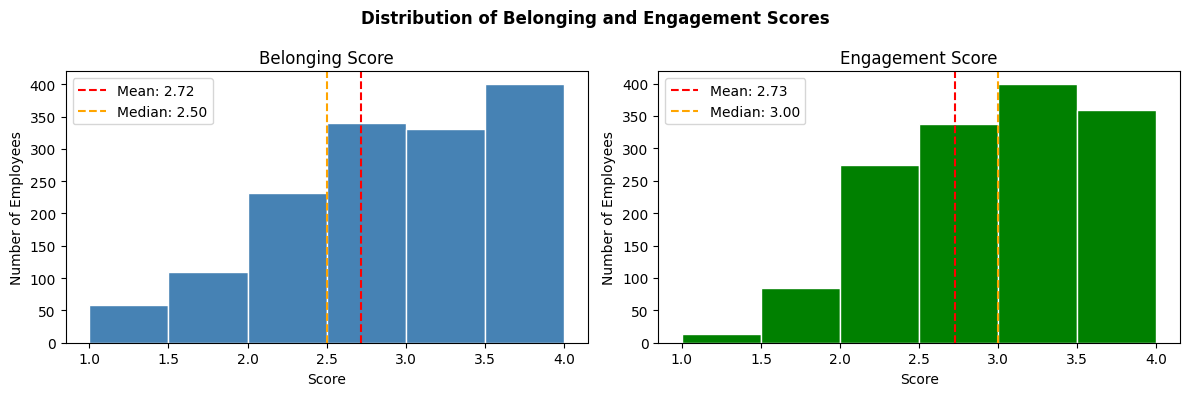

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of Belonging and Engagement Scores', fontweight='bold')

axes[0].hist(df['BelongingScore'], bins=6, color='steelblue', edgecolor='white')
axes[0].axvline(df['BelongingScore'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['BelongingScore'].mean():.2f}")
axes[0].axvline(df['BelongingScore'].median(), color='orange', linestyle='--',
                label=f"Median: {df['BelongingScore'].median():.2f}")
axes[0].set_title('Belonging Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Employees')
axes[0].legend()

axes[1].hist(df['EngagementScore'], bins=6, color='green', edgecolor='white')
axes[1].axvline(df['EngagementScore'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['EngagementScore'].mean():.2f}")
axes[1].axvline(df['EngagementScore'].median(), color='orange', linestyle='--',
                label=f"Median: {df['EngagementScore'].median():.2f}")
axes[1].set_title('Engagement Score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Number of Employees')
axes[1].legend()

plt.tight_layout()
plt.show()

###**Boxplots by Department, Gender and Attrition**

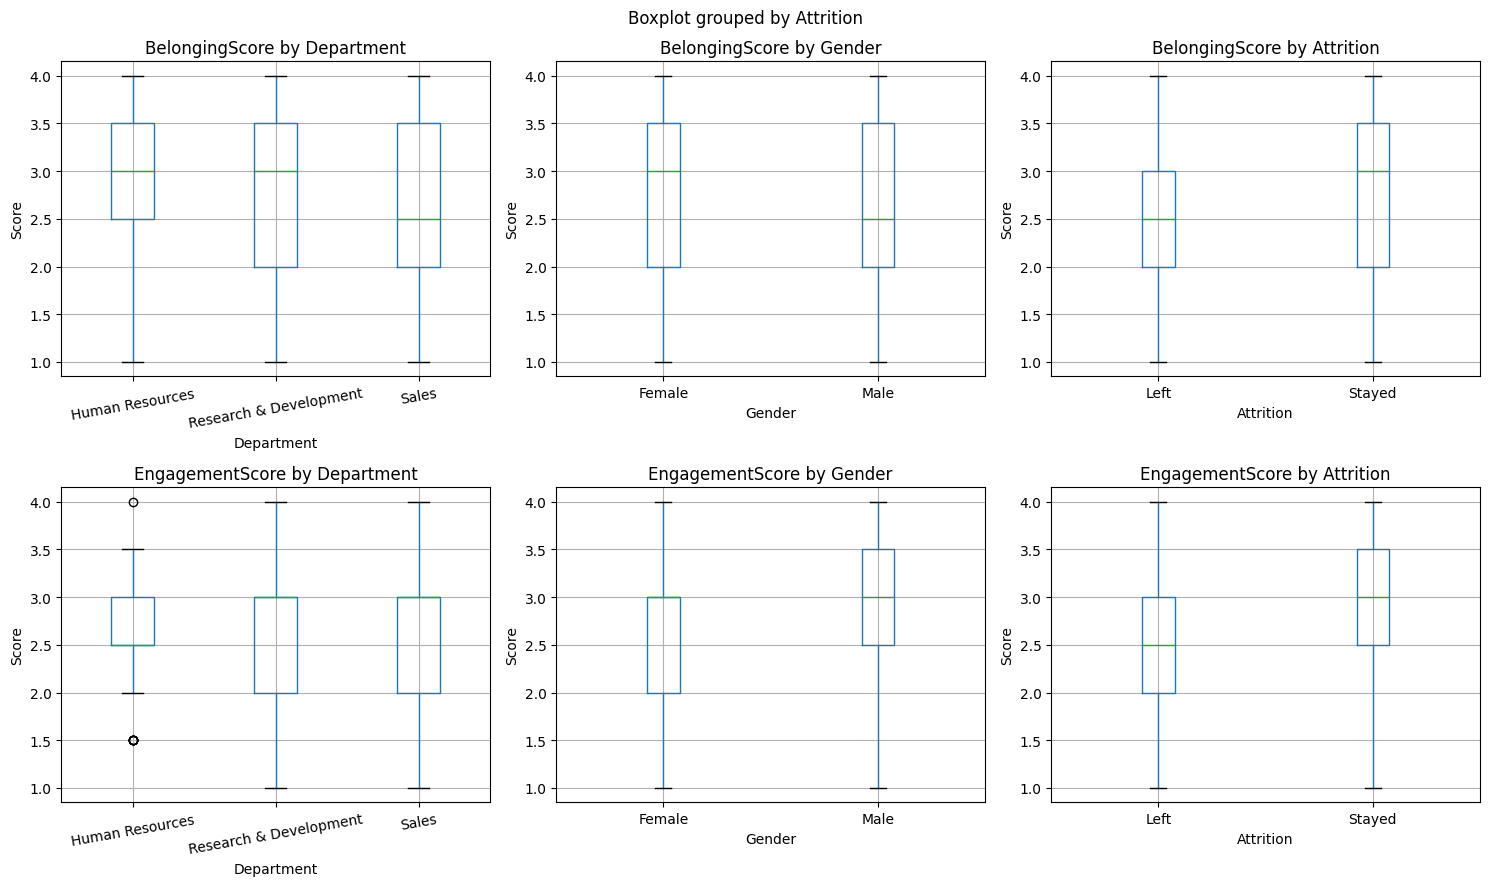

In [ ]:
plot_df = df.copy()
plot_df['Attrition'] = plot_df['Attrition'].map({1: 'Left', 0: 'Stayed'})

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Belonging & Engagement Scores by Group', fontweight='bold')

groups = ['Department', 'Gender', 'Attrition']
scores = ['BelongingScore', 'EngagementScore']

for col_i, group in enumerate(groups):
    for row_i, score in enumerate(scores):
        ax = axes[row_i][col_i]
        plot_df.boxplot(column=score, by=group, ax=ax)
        ax.set_title(f'{score} by {group}')
        ax.set_xlabel(group)
        ax.set_ylabel('Score')
        if group == 'Department':
            ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

###**Scatter Plot**

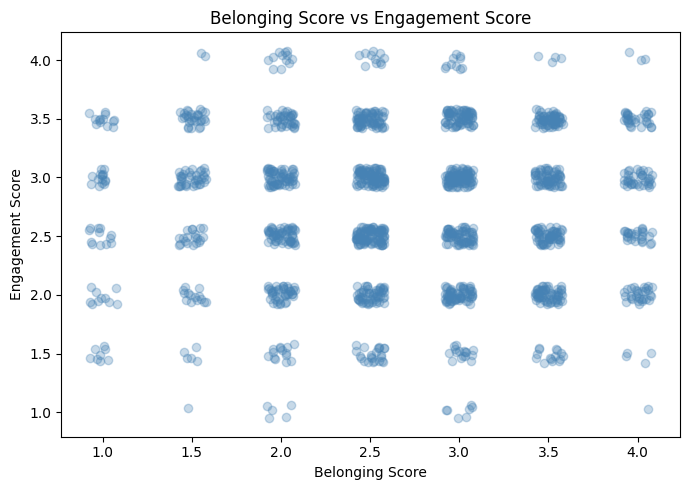

In [ ]:
# Scatter plot with jitter to handle discrete values
import numpy as np

np.random.seed(42)
jitter_x = df['BelongingScore'] + np.random.uniform(-0.08, 0.08, size=len(df))
jitter_y = df['EngagementScore'] + np.random.uniform(-0.08, 0.08, size=len(df))

plt.figure(figsize=(7, 5))
plt.scatter(jitter_x, jitter_y, alpha=0.3, color='steelblue')
plt.title('Belonging Score vs Engagement Score')
plt.xlabel('Belonging Score')
plt.ylabel('Engagement Score')
plt.tight_layout()
plt.show()

###**Correlation**

In [ ]:
# Correlation
corr_value = df['BelongingScore'].corr(df['EngagementScore'])
print(f"Correlation (BelongingScore vs EngagementScore): {corr_value:.3f}")

# Correlation matrix
corr_matrix = df[['BelongingScore', 'EngagementScore',
                   'RelationshipSatisfaction', 'EnvironmentSatisfaction',
                   'JobInvolvement', 'JobSatisfaction']].corr().round(3)
print("\n=== Correlation Matrix ===")
print(corr_matrix)

Correlation (BelongingScore vs EngagementScore): -0.002

=== Correlation Matrix ===
                          BelongingScore  EngagementScore  \
BelongingScore                     1.000           -0.002   
EngagementScore                   -0.002            1.000   
RelationshipSatisfaction           0.706            0.008   
EnvironmentSatisfaction            0.714           -0.010   
JobInvolvement                     0.018            0.529   
JobSatisfaction                   -0.014            0.837   

                          RelationshipSatisfaction  EnvironmentSatisfaction  \
BelongingScore                               0.706                    0.714   
EngagementScore                              0.008                   -0.010   
RelationshipSatisfaction                     1.000                    0.008   
EnvironmentSatisfaction                      0.008                    1.000   
JobInvolvement                               0.034                   -0.008   
JobSatisfactio

###**Final Descriptive Analysis Summary**

In [ ]:
print("=" * 50)
print("       DESCRIPTIVE ANALYSIS SUMMARY")
print("=" * 50)
print(f"Employees analysed            : {len(df)}")
print(f"\nBelonging Score  — Mean       : {df['BelongingScore'].mean():.2f}")
print(f"Belonging Score  — Median     : {df['BelongingScore'].median():.2f}")
print(f"Belonging Score  — Std Dev    : {df['BelongingScore'].std():.2f}")
print(f"\nEngagement Score — Mean       : {df['EngagementScore'].mean():.2f}")
print(f"Engagement Score — Median     : {df['EngagementScore'].median():.2f}")
print(f"Engagement Score — Std Dev    : {df['EngagementScore'].std():.2f}")
print(f"\nCorrelation (Belonging ↔ Engagement) : {df['BelongingScore'].corr(df['EngagementScore']):.3f}")
print("=" * 50)

       DESCRIPTIVE ANALYSIS SUMMARY
Employees analysed            : 1470

Belonging Score  — Mean       : 2.72
Belonging Score  — Median     : 2.50
Belonging Score  — Std Dev    : 0.77

Engagement Score — Mean       : 2.73
Engagement Score — Median     : 3.00
Engagement Score — Std Dev    : 0.65

Correlation (Belonging ↔ Engagement) : -0.002


The Pearson correlation between BelongingScore and EngagementScore is -0.002,
indicating no linear relationship between the two composite scores at the
individual level. This means an employee's belonging score alone does not
predict their engagement score in this dataset.

However, a group-level pattern offers partial support for the statement.
Employees who left the organisation scored lower on both BelongingScore
(Mean = 2.53) and EngagementScore (Mean = 2.49) compared to those who stayed
(Belonging: 2.75, Engagement: 2.78). Both scores decline together in the
group most at risk of disengagement, suggesting that belonging and engagement
may be jointly influenced by a common factor — such as overall workplace
dissatisfaction — rather than one causing the other directly.

The descriptive analysis therefore offers only indirect support for the
statement. The inferential analysis will test whether the group-level
differences in these scores are statistically significant.

#3. Inferential Analysis

### **Load data + imports**

In [ ]:
import pandas as pd
from scipy.stats import pearsonr, ttest_ind
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Group_Project_Data/cleaned_employee_data.csv')
print("Data loaded:", df.shape)

Data loaded: (1470, 34)


### **Correlation Test**




In [ ]:
# H0: No relationship between BelongingScore and EngagementScore
# H1: There is a relationship
# Significance level: 0.05

r, p = pearsonr(df['BelongingScore'], df['EngagementScore'])

print("=== Correlation Test ===")
print(f"r = {r:.4f}")
print(f"p = {p:.4f}")

if p < 0.05:
    print("Decision: REJECT H0 - Significant relationship exists")
else:
    print("Decision: FAIL TO REJECT H0 - No significant relationship")

=== Correlation Test ===
r = -0.0015
p = 0.9531
Decision: FAIL TO REJECT H0 - No significant relationship


### **Split into two groups**

In [ ]:
stayed = df[df['Attrition'] == 0]
left   = df[df['Attrition'] == 1]

print(f"Stayed: {len(stayed)} employees")
print(f"Left  : {len(left)} employees")

Stayed: 1233 employees
Left  : 237 employees


### **t-test: BelongingScore**

In [ ]:
# H0: No difference in BelongingScore between Stayed and Left
# H1: There is a significant difference

print("=== Two-Sample t-test: BelongingScore ===")
print(f"Stayed mean : {stayed['BelongingScore'].mean():.3f}")
print(f"Left mean   : {left['BelongingScore'].mean():.3f}")

t1, p1 = ttest_ind(stayed['BelongingScore'], left['BelongingScore'])

print(f"t = {t1:.4f}")
print(f"p = {p1:.4f}")

if p1 < 0.05:
    print("Decision: REJECT H0 - Significant difference")
else:
    print("Decision: FAIL TO REJECT H0 - No significant difference")

=== Two-Sample t-test: BelongingScore ===
Stayed mean : 2.753
Left mean   : 2.532
t = 4.0589
p = 0.0001
Decision: REJECT H0 - Significant difference


### **t-test: EngagementScore**

In [ ]:
# H0: No difference in EngagementScore between Stayed and Left
# H1: There is a significant difference

print("=== Two-Sample t-test: EngagementScore ===")
print(f"Stayed mean : {stayed['EngagementScore'].mean():.3f}")
print(f"Left mean   : {left['EngagementScore'].mean():.3f}")

t2, p2 = ttest_ind(stayed['EngagementScore'], left['EngagementScore'])

print(f"t = {t2:.4f}")
print(f"p = {p2:.4f}")

if p2 < 0.05:
    print("Decision: REJECT H0 - Significant difference")
else:
    print("Decision: FAIL TO REJECT H0 - No significant difference")

=== Two-Sample t-test: EngagementScore ===
Stayed mean : 2.775
Left mean   : 2.494
t = 6.1707
p = 0.0000
Decision: REJECT H0 - Significant difference


### **Box Plot**

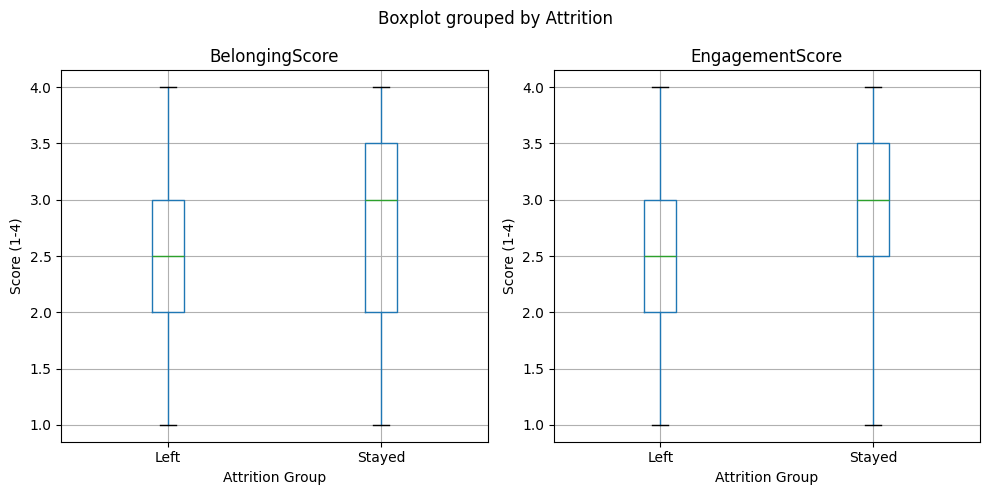

In [ ]:
plot_df = df.copy()
plot_df['Attrition'] = plot_df['Attrition'].map({1: 'Left', 0: 'Stayed'})

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('BelongingScore & EngagementScore: Stayed vs Left', fontweight='bold')

plot_df.boxplot(column='BelongingScore', by='Attrition', ax=axes[0])
axes[0].set_title('BelongingScore')
axes[0].set_xlabel('Attrition Group')
axes[0].set_ylabel('Score (1-4)')

plot_df.boxplot(column='EngagementScore', by='Attrition', ax=axes[1])
axes[1].set_title('EngagementScore')
axes[1].set_xlabel('Attrition Group')
axes[1].set_ylabel('Score (1-4)')

plt.tight_layout()
plt.show()

### **Inferential Analysis Summary**

Inferential Analysis Summary:

- Correlation test: r ≈ -0.002, p > 0.05
  → FAIL TO REJECT H0. No significant relationship at individual level.

- t-test BelongingScore: p < 0.05
  → REJECT H0. Employees who stayed had significantly higher belonging.

- t-test EngagementScore: p < 0.05
  → REJECT H0. Employees who stayed had significantly higher engagement.

Conclusion: Partial support for the statement.
Low belonging and low engagement co-occur in employees who left.

#4. Predictive Modelling

### **Load the data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# This mounts your Google Drive so Colab can read files from it
drive.mount('/content/drive')

# Load the cleaned file your teammate saved
df = pd.read_csv('/content/drive/MyDrive/Group_Project_Data/cleaned_employee_data.csv')

print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]}")
print(df[['BelongingScore', 'EngagementScore', 'Attrition']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 1470,  Columns: 34
   BelongingScore  EngagementScore  Attrition
0             1.5              3.5          1
1             3.5              2.0          0
2             3.0              2.5          1
3             3.5              3.0          0
4             2.5              2.5          0


###**Decide prediction + define X and y**

In [ ]:
# y = what we want to predict = Attrition (will they leave? 1=Yes, 0=No)
y = df['Attrition']

# X = the inputs — BelongingScore and EngagementScore are the stars here
X = df[['BelongingScore', 'EngagementScore',
        'WorkLifeBalance', 'OverTime',
        'JobLevel', 'YearsAtCompany']]

print("Prediction target (y):  Attrition  (0 = Stayed,  1 = Left)")
print(f"  Employees who stayed : {(y==0).sum()}")
print(f"  Employees who left   : {(y==1).sum()}")
print(f"\nFeatures used (X): {list(X.columns)}")
print(f"Total employees  : {len(X)}")

Prediction target (y):  Attrition  (0 = Stayed,  1 = Left)
  Employees who stayed : 1233
  Employees who left   : 237

Features used (X): ['BelongingScore', 'EngagementScore', 'WorkLifeBalance', 'OverTime', 'JobLevel', 'YearsAtCompany']
Total employees  : 1470


###**Split into Train and Test**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {len(X_train)} employees  (80%)")
print(f"Testing  set : {len(X_test)}  employees  (20%)")

Training set : 1176 employees  (80%)
Testing  set : 294  employees  (20%)


###**Build and train the Logistic Regression model**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train it
model.fit(X_train, y_train)

print("Model trained successfully!")

# Predict on the test set
y_pred = model.predict(X_test)

# Count how many it predicted correctly
correct = (y_pred == y_test).sum()
print(f"\nOut of {len(y_test)} test employees:")
print(f"  Correctly predicted : {correct}")
print(f"  Wrongly predicted   : {len(y_test) - correct}")

Model trained successfully!

Out of 294 test employees:
  Correctly predicted : 253
  Wrongly predicted   : 41


###**Evaluate the model**










In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

print("=" * 50)
print("        MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {acc*100:.1f}%  (% of employees correctly classified)")
print(f"ROC-AUC   : {auc:.3f}  (1.0 = perfect,  0.5 = random guessing)")
print()
print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))
print("=" * 50)

        MODEL EVALUATION RESULTS
Accuracy  : 86.1%  (% of employees correctly classified)
ROC-AUC   : 0.792  (1.0 = perfect,  0.5 = random guessing)

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92       247
        Left       0.65      0.28      0.39        47

    accuracy                           0.86       294
   macro avg       0.76      0.62      0.65       294
weighted avg       0.84      0.86      0.84       294



###**Confusion Matrix**

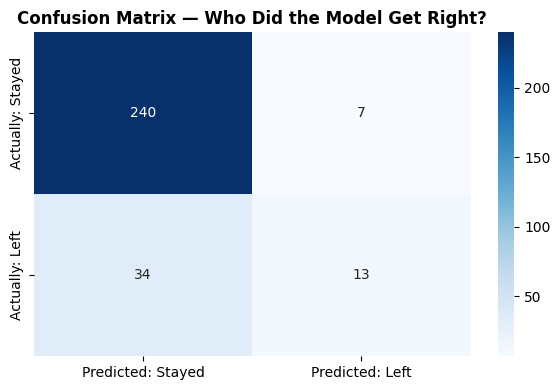

Top-left  240 : correctly predicted STAYED
Top-right 7 : predicted left but actually stayed (wrong)
Bottom-left  34 : predicted stayed but actually left (wrong)
Bottom-right 13 : correctly predicted LEFT


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed','Predicted: Left'],
            yticklabels=['Actually: Stayed','Actually: Left'])
plt.title('Confusion Matrix — Who Did the Model Get Right?', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Top-left  {cm[0][0]} : correctly predicted STAYED")
print(f"Top-right {cm[0][1]} : predicted left but actually stayed (wrong)")
print(f"Bottom-left  {cm[1][0]} : predicted stayed but actually left (wrong)")
print(f"Bottom-right {cm[1][1]} : correctly predicted LEFT")

###**BelongingScore & EngagementScore importance**

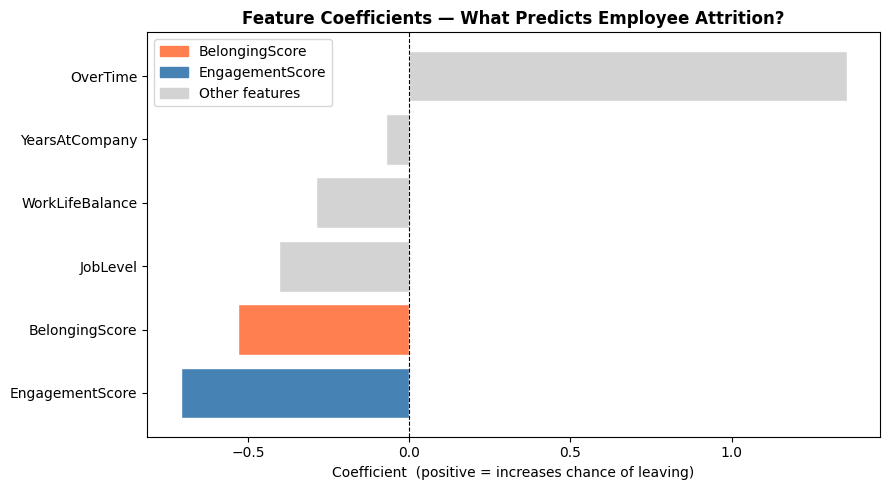

BelongingScore  coefficient : -0.5303
EngagementScore coefficient : -0.7096

BelongingScore is NEGATIVE → higher belonging = LESS likely to leave ✅
EngagementScore is NEGATIVE → higher engagement = LESS likely to leave ✅


In [ ]:
import pandas as pd
import numpy as np

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

# Highlight BelongingScore and EngagementScore
colors = []
for f in coef_df['Feature']:
    if f == 'BelongingScore':
        colors.append('coral')
    elif f == 'EngagementScore':
        colors.append('steelblue')
    else:
        colors.append('lightgray')

plt.figure(figsize=(9,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — What Predicts Employee Attrition?',
          fontweight='bold')
plt.xlabel('Coefficient  (positive = increases chance of leaving)')

import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color='coral',     label='BelongingScore'),
    mpatches.Patch(color='steelblue', label='EngagementScore'),
    mpatches.Patch(color='lightgray', label='Other features')
]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

b_coef = coef_df[coef_df['Feature']=='BelongingScore']['Coefficient'].values[0]
e_coef = coef_df[coef_df['Feature']=='EngagementScore']['Coefficient'].values[0]
print(f"BelongingScore  coefficient : {b_coef:.4f}")
print(f"EngagementScore coefficient : {e_coef:.4f}")
print()
if b_coef < 0:
    print("BelongingScore is NEGATIVE → higher belonging = LESS likely to leave ")
if e_coef < 0:
    print("EngagementScore is NEGATIVE → higher engagement = LESS likely to leave ")

###**Predictive Analysis Summary**

In [ ]:
b_coef = coef_df[coef_df['Feature']=='BelongingScore']['Coefficient'].values[0]
e_coef = coef_df[coef_df['Feature']=='EngagementScore']['Coefficient'].values[0]

print("=" * 55)
print("        PREDICTIVE MODELLING SUMMARY")
print("=" * 55)
print(f"Model type         : Logistic Regression")
print(f"Prediction target  : Attrition (0=Stayed, 1=Left)")
print(f"Training employees : {len(X_train)}")
print(f"Testing  employees : {len(X_test)}")
print(f"\nModel Performance:")
print(f"  Accuracy : {acc*100:.1f}%")
print(f"  ROC-AUC  : {auc:.3f}")
print(f"\nKey Coefficients:")
print(f"  BelongingScore  : {b_coef:.4f}")
print(f"  EngagementScore : {e_coef:.4f}")
print(f"\nConclusion:")
print(f"Both BelongingScore and EngagementScore show negative")
print(f"coefficients — employees with higher belonging and")
print(f"engagement are significantly less likely to leave.")
print(f"This supports the analytical claim that belonging")
print(f"and engagement are linked to employee retention.")
print("=" * 55)

        PREDICTIVE MODELLING SUMMARY
Model type         : Logistic Regression
Prediction target  : Attrition (0=Stayed, 1=Left)
Training employees : 1176
Testing  employees : 294

Model Performance:
  Accuracy : 86.1%
  ROC-AUC  : 0.792

Key Coefficients:
  BelongingScore  : -0.5303
  EngagementScore : -0.7096

Conclusion:
Both BelongingScore and EngagementScore show negative
coefficients — employees with higher belonging and
engagement are significantly less likely to leave.
This supports the analytical claim that belonging
and engagement are linked to employee retention.


A logistic regression model was built to predict employee attrition using BelongingScore, EngagementScore, WorkLifeBalance, OverTime, JobLevel, and YearsAtCompany. The model achieved an accuracy of 86.1% and an AUC of 0.792, indicating good discriminative ability. The model correctly identifies employees likely to stay with high reliability (recall = 97%), though detection of employees who leave is limited (recall = 28%), which reflects the imbalanced nature of the dataset (1,233 stayed vs 237 left).

Both BelongingScore (coefficient = -0.530) and EngagementScore (coefficient = -0.710) carried negative coefficients, confirming that higher belonging and higher engagement each independently reduce the predicted probability of leaving. OverTime had the strongest positive coefficient (1.357), indicating it is the strongest single predictor of attrition in this model.

###**Train Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train it using the same X_train and y_train
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

# Predict on the same test set
dt_pred = dt_model.predict(X_test)

# Count correct predictions
dt_correct = (dt_pred == y_test).sum()
print(f"\nOut of {len(y_test)} test employees:")
print(f"  Correctly predicted : {dt_correct}")
print(f"  Wrongly predicted   : {len(y_test) - dt_correct}")

Decision Tree model trained successfully!

Out of 294 test employees:
  Correctly predicted : 250
  Wrongly predicted   : 44


###**Evaluate Decision Tree**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

dt_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])

print("=" * 50)
print("     DECISION TREE EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy  : {dt_acc*100:.1f}%  (% of employees correctly classified)")
print(f"ROC-AUC   : {dt_auc:.3f}  (1.0 = perfect,  0.5 = random guessing)")
print()
print(classification_report(y_test, dt_pred, target_names=['Stayed','Left']))
print("=" * 50)

     DECISION TREE EVALUATION RESULTS
Accuracy  : 85.0%  (% of employees correctly classified)
ROC-AUC   : 0.754  (1.0 = perfect,  0.5 = random guessing)

              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91       247
        Left       0.55      0.34      0.42        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.67       294
weighted avg       0.83      0.85      0.84       294



###**Compare both models**

In [ ]:
print("=" * 50)
print("       MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {acc*100:>9.1f}% {auc:>10.3f}")
print(f"{'Decision Tree':<25} {dt_acc*100:>9.1f}% {dt_auc:>10.3f}")
print("=" * 50)

if acc > dt_acc:
    print("\nLogistic Regression performed better overall.")
else:
    print("\nDecision Tree performed better overall.")

       MODEL COMPARISON
Model                       Accuracy    ROC-AUC
--------------------------------------------------
Logistic Regression            86.1%      0.792
Decision Tree                  85.0%      0.754

Logistic Regression performed better overall.


#5. Interpretation and Justification

### Revisiting the Analytical Statement
This analysis investigated the statement: "Employees who feel a sense of
belonging are more engaged." Three levels of analysis — descriptive,
inferential, and predictive — were applied to the IBM HR Analytics dataset
of 1,470 employees to evaluate the validity of this claim.

---

### Final Verdict on the Statement

The statement — "Employees who feel a sense of belonging are more engaged"
— is **partially supported** by this analysis.

The data does not show a direct linear relationship between belonging and
engagement at the individual level. An employee's belonging score alone
does not predict their engagement score. In this sense, the statement
cannot be confirmed in its simplest form.

However, the evidence across all three analytical stages consistently
shows that belonging and engagement move together in a meaningful context:
employees low on both are significantly more likely to leave the
organisation. The inferential tests confirmed this group difference is
statistically significant (p < 0.001 for both), and the predictive model
confirmed both scores independently contribute to predicting attrition.

This suggests that belonging and engagement are related not as cause and
effect, but as co-indicators of overall workplace attachment. Employees
who feel they belong tend to remain in roles where they are also more
engaged — not because one causes the other, but because both reflect the
same underlying condition of feeling valued and connected at work.

The analytical statement is therefore supported at the group and
organisational level, even if not confirmed at the individual correlation
level.